# Generative RNNs: Text Completion

**Data source:** ArSenTD-LEV - Arabic Sentiment Twitter Dataset for Levantine dialect

**Repository:** https://github.com/aub-mind/hULMonA

**Direct download:** https://raw.githubusercontent.com/aub-mind/hULMonA/master/data/ArSenTD-LEV.tsv

In this notebook, we'll build a **generative RNN** that can complete sentences. Given the first half of a tweet, the model will predict the next 30 characters.

**Key differences from classification:**
- **Classification**: Sequence → single label (sentiment)
- **Generation**: Sequence → sequence (text continuation)

**Learning objectives:**
- Understand sequence-to-sequence prediction
- Learn about teacher forcing in training
- Implement autoregressive generation
- Understand sampling strategies (greedy, temperature-based)
- See how RNNs can generate coherent text

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import time

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Part 1: Load and Prepare Data

We'll use the same Lebanese Arabic tweets dataset, but this time we'll prepare it for generation:
- Split each tweet into input (first half) and target (next 30 characters)
- Train the model to predict character-by-character

In [2]:
# Load data
df = pd.read_csv('ArSenTD-LEV.tsv', sep='\t')
df_lebanese = df[df['Country'] == 'lebanon'].copy()

# Use all tweets for generation (don't need labels)
tweets = df_lebanese['Tweet'].values

print(f"Total tweets: {len(tweets)}")
print(f"\nExample tweets:")
for i in range(5):
    print(f"{i+1}. {tweets[i][:100]}...")

Total tweets: 1000

Example tweets:
1. "أنا أؤمن بأن الانسان ينطفئ جماله عند ابتعاد من يحب ، حتى بريق العيون يختفي فيصبح ذابلاً منطفئًا، يت...
2. #مصطلحات_لبنانيه_حيرت_البشريه بتوصل عالبيت ، بنط واحد بقلك "جيت؟" , بتقعد لتتحدث معو بقلك "شو في ما ...
3. لا تستسلم للمصاعب والأزمات، بل تحدَّها بالإيمان والصبر ، فكل العظماء كافحوا وتحمّلوا المشاقّ حتى وصل...
4. الف الف مبروك للمنتخب السوري كسب احترام الجميع لعب بروح والعزيمه شكرا على كل شي قدمتوه على مدار التص...
5. شو حلو الشعور لما تحاول تدرس شي مش فاهمو بالصف و الدكتور ما خصو بشي اسمو شرح و تفهم كل شي لحالك انو ...


In [3]:
# Build character vocabulary
all_text = ' '.join(tweets)
unique_chars = sorted(set(all_text))

# IMPORTANT: Reserve index 0 for padding, shift all characters by +1
# This prevents space (which would be at index 0) from being treated as padding
char_to_idx = {ch: idx+1 for idx, ch in enumerate(unique_chars)}
char_to_idx['<PAD>'] = 0  # Explicit padding token

idx_to_char = {idx: ch for ch, idx in char_to_idx.items()}

vocab_size = len(char_to_idx)
print(f"Vocabulary size: {vocab_size} (including <PAD>)")
print(f"\nFirst 20 characters: {unique_chars[:20]}")
print(f"Last 20 characters: {unique_chars[-20:]}")
print(f"\nSpace character is at index: {char_to_idx[' ']}")
print(f"Padding <PAD> is at index: {char_to_idx['<PAD>']}")

Vocabulary size: 246 (including <PAD>)

First 20 characters: [' ', '!', '"', '#', '$', '%', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5']
Last 20 characters: ['😟', '😤', '😨', '😩', '😭', '😶', '😻', '🙂', '🙃', '🙄', '🙆', '🙊', '🙌', '🙏', '🤔', '🤣', '🤦', '🤧', '🤲', '🤷']

Space character is at index: 1
Padding <PAD> is at index: 0


**Important fix:**

We shift all character indices by +1 to reserve index 0 for padding. This ensures:
- `<PAD>` token: index 0 (used for padding sequences)
- Space character: index 1 (not confused with padding)
- All other characters: indices 2-246

Without this fix, spaces would be at index 0 and treated as padding, causing the model to suppress spaces in generation.

## Part 2: Prepare Training Data

**Task setup:**
- Given: First half of a tweet (input sequence)
- Predict: Next 30 characters (target sequence)

**Example:**
- Tweet: "Hello world, this is a test message"
- Input: "Hello world, th" (first 15 chars)
- Target: "is is a test message" (next 30 chars)

**Training approach:**
- For each position in the target, predict the next character
- Use **teacher forcing**: feed the ground truth at each step during training

In [4]:
def create_training_pairs(tweets, min_length=60, target_length=30):
    """
    Create (input, target) pairs for text generation.
    
    Args:
        tweets: List of tweet strings
        min_length: Minimum tweet length to use
        target_length: Number of characters to predict
    
    Returns:
        inputs: List of input sequences (first half)
        targets: List of target sequences (next target_length chars)
    """
    inputs = []
    targets = []
    
    for tweet in tweets:
        if len(tweet) < min_length:
            continue
            
        # Split at midpoint
        mid_point = len(tweet) // 2
        
        # Make sure we have enough characters for the target
        if len(tweet) - mid_point < target_length:
            continue
            
        input_text = tweet[:mid_point]
        target_text = tweet[mid_point:mid_point + target_length]
        
        inputs.append(input_text)
        targets.append(target_text)
    
    return inputs, targets

inputs, targets = create_training_pairs(tweets, min_length=60, target_length=30)

print(f"Training pairs: {len(inputs)}")
print(f"\nExample pairs:")
for i in range(3):
    print(f"\n{i+1}.")
    print(f"   Input:  [{inputs[i]}]")
    print(f"   Target: [{targets[i]}]")

Training pairs: 1000

Example pairs:

1.
   Input:  ["أنا أؤمن بأن الانسان ينطفئ جماله عند ابتعاد من يحب ، حتى بريق الع]
   Target: [يون يختفي فيصبح ذابلاً منطفئًا]

2.
   Input:  [#مصطلحات_لبنانيه_حيرت_البشريه بتوصل عالبيت ، بنط واحد بقلك "جيت؟" ,]
   Target: [ بتقعد لتتحدث معو بقلك "شو في ]

3.
   Input:  [لا تستسلم للمصاعب والأزمات، بل تحدَّها بالإيمان والصبر ، فكل العظ]
   Target: [ماء كافحوا وتحمّلوا المشاقّ حت]


In [5]:
def encode_sequence(text, char_to_idx):
    """Convert text to list of character indices"""
    return [char_to_idx[ch] for ch in text]

def decode_sequence(indices, idx_to_char):
    """Convert list of indices back to text"""
    return ''.join([idx_to_char[idx] for idx in indices])

# Encode all sequences
inputs_encoded = [encode_sequence(text, char_to_idx) for text in inputs]
targets_encoded = [encode_sequence(text, char_to_idx) for text in targets]

print(f"Example encoding:")
print(f"Original: {inputs[0][:20]}")
print(f"Encoded:  {inputs_encoded[0][:20]}")
print(f"Decoded:  {decode_sequence(inputs_encoded[0][:20], idx_to_char)}")
print(f"\nSpace character (should not be 0): {char_to_idx[' ']}")

Example encoding:
Original: "أنا أؤمن بأن الانسا
Encoded:  [3, 92, 122, 96, 1, 92, 93, 121, 122, 1, 97, 92, 122, 1, 96, 120, 96, 122, 108, 96]
Decoded:  "أنا أؤمن بأن الانسا

Space character (should not be 0): 1


In [6]:
# Pad sequences to have uniform length
def pad_sequence(seq, max_len, pad_value=0):
    """Pad sequence to max_len with padding token (index 0)"""
    if len(seq) < max_len:
        return seq + [pad_value] * (max_len - len(seq))
    return seq[:max_len]

# Find max lengths
max_input_len = max(len(seq) for seq in inputs_encoded)
target_len = 30  # Fixed target length

print(f"Max input length: {max_input_len}")
print(f"Target length: {target_len}")

# Pad all sequences
inputs_padded = [pad_sequence(seq, max_input_len) for seq in inputs_encoded]
targets_padded = [pad_sequence(seq, target_len) for seq in targets_encoded]

# Convert to numpy arrays
inputs_array = np.array(inputs_padded)
targets_array = np.array(targets_padded)

print(f"\nInput shape: {inputs_array.shape}")
print(f"Target shape: {targets_array.shape}")

Max input length: 73
Target length: 30

Input shape: (1000, 73)
Target shape: (1000, 30)


In [7]:
# Split into train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    inputs_array, targets_array, test_size=0.2, random_state=42
)

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Train samples: 800
Test samples: 200


In [8]:
# Create PyTorch datasets
class GenerativeDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = torch.LongTensor(inputs)
        self.targets = torch.LongTensor(targets)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

train_dataset = GenerativeDataset(X_train, y_train)
test_dataset = GenerativeDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 25
Test batches: 7


## Part 3: Generative RNN Architecture

**Key differences from classification RNN:**

**Classification RNN:**
- Input: sequence of characters
- Output: single vector (final hidden state) → class logits
- Loss: cross-entropy on single prediction

**Generative RNN:**
- Input: sequence of characters
- Output: sequence of character logits (one per position)
- Loss: cross-entropy at each time step (summed or averaged)

**Architecture:**
```
Input: [c1, c2, c3, ..., cn]
  ↓
Embedding: [e1, e2, e3, ..., en]
  ↓
RNN: [h1, h2, h3, ..., hn]
  ↓
Linear: [logits1, logits2, ..., logits30]
  ↓
Output: [char1, char2, ..., char30]
```

In [9]:
class GenerativeRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, 
                 target_length=30, dropout=0.3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.target_length = target_length
        
        # Embedding layer (padding_idx=0 for <PAD> token)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # RNN layer
        self.rnn = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Output layer: hidden_dim → vocab_size (for each character)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        # x: (batch_size, seq_len)
        batch_size = x.size(0)
        
        # Embed input
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        
        # Pass through RNN
        if hidden is None:
            rnn_out, hidden = self.rnn(embedded)  # rnn_out: (batch_size, seq_len, hidden_dim)
        else:
            rnn_out, hidden = self.rnn(embedded, hidden)
        
        # Use the final hidden state to generate target_length characters
        final_hidden = hidden  # (1, batch_size, hidden_dim)
        
        # Generate target_length predictions
        outputs = []
        current_hidden = final_hidden
        
        # Start with a dummy input (we'll use teacher forcing during training)
        for t in range(self.target_length):
            # Take hidden state
            h = current_hidden.squeeze(0)  # (batch_size, hidden_dim)
            
            # Apply dropout and linear layer
            h = self.dropout(h)
            logits = self.fc(h)  # (batch_size, vocab_size)
            outputs.append(logits)
        
        # Stack outputs: (target_length, batch_size, vocab_size) → (batch_size, target_length, vocab_size)
        outputs = torch.stack(outputs, dim=1)
        
        return outputs
    
    def generate(self, x, temperature=1.0):
        """
        Generate text autoregressively.
        
        Args:
            x: Input sequence (batch_size, seq_len)
            temperature: Sampling temperature (higher = more random)
        """
        self.eval()
        with torch.no_grad():
            batch_size = x.size(0)
            
            # Process input
            embedded = self.embedding(x)
            _, hidden = self.rnn(embedded)
            
            # Generate target_length characters
            generated = []
            current_hidden = hidden
            
            for t in range(self.target_length):
                h = current_hidden.squeeze(0)
                logits = self.fc(h)  # (batch_size, vocab_size)
                
                # Apply temperature
                logits = logits / temperature
                
                # Sample from distribution
                probs = torch.softmax(logits, dim=-1)
                next_char = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)
                generated.append(next_char.squeeze(1))
                
                # Use predicted character as input for next step
                next_embedded = self.embedding(next_char)  # (batch_size, 1, embedding_dim)
                _, current_hidden = self.rnn(next_embedded, current_hidden)
            
            # Stack: (batch_size, target_length)
            generated = torch.stack(generated, dim=1)
            
        return generated

**Model architecture explanation:**

1. **Embedding**: Maps character indices to dense vectors (vocab_size → 128)
   - `padding_idx=0` ensures `<PAD>` tokens get zero embeddings
2. **GRU**: Processes the input sequence, maintains hidden state (128 → 256)
3. **Generation loop**: Starting from final hidden state, generate 30 characters
   - At each step: hidden state → linear layer → character logits
   - During training: use teacher forcing (feed ground truth)
   - During generation: use predicted character as next input
4. **Sampling**: Use temperature-controlled sampling for diversity

In [10]:
# Create model
model = GenerativeRNN(vocab_size, embedding_dim=128, hidden_dim=256, 
                      target_length=30, dropout=0.3)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(model)

Total parameters: 391,158
Trainable parameters: 391,158

Model architecture:
GenerativeRNN(
  (embedding): Embedding(246, 128, padding_idx=0)
  (rnn): GRU(128, 256, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=246, bias=True)
)


## Part 4: Training with Teacher Forcing

**Teacher forcing** is a training technique for sequence-to-sequence models:

**Without teacher forcing:**
- Use model's own predictions as input for next step
- Errors accumulate (if first prediction is wrong, subsequent ones are affected)
- Slow convergence

**With teacher forcing:**
- Use ground truth as input for next step (during training)
- Faster convergence
- But creates train-test mismatch (exposure bias)

**Solution:** Use teacher forcing during training, autoregressive generation during inference.

In [11]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch with teacher forcing"""
    model.train()
    total_loss = 0
    total_chars = 0
    correct_chars = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        batch_size = inputs.size(0)

        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)  # (batch_size, target_length, vocab_size)
        
        # Reshape for loss computation
        # outputs: (batch_size * target_length, vocab_size)
        # targets: (batch_size * target_length)
        outputs_flat = outputs.view(-1, vocab_size)
        targets_flat = targets.view(-1)
        
        # Compute loss
        loss = criterion(outputs_flat, targets_flat)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping (prevent exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        
        optimizer.step()

        total_loss += loss.item()
        
        # Compute character-level accuracy
        _, predicted = outputs.max(dim=2)  # (batch_size, target_length)
        correct_chars += (predicted == targets).sum().item()
        total_chars += targets.numel()

    avg_loss = total_loss / len(loader)
    char_accuracy = 100. * correct_chars / total_chars
    
    return avg_loss, char_accuracy

def evaluate(model, loader, criterion, device):
    """Evaluate on test set"""
    model.eval()
    total_loss = 0
    total_chars = 0
    correct_chars = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            
            outputs_flat = outputs.view(-1, vocab_size)
            targets_flat = targets.view(-1)
            
            loss = criterion(outputs_flat, targets_flat)
            total_loss += loss.item()
            
            _, predicted = outputs.max(dim=2)
            correct_chars += (predicted == targets).sum().item()
            total_chars += targets.numel()

    avg_loss = total_loss / len(loader)
    char_accuracy = 100. * correct_chars / total_chars
    
    return avg_loss, char_accuracy

In [12]:
# Training setup
criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignore padding
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Track metrics
train_losses = []
test_losses = []
train_accs = []
test_accs = []

# Train
epochs = 20
print("Starting training...\n")
start_time = time.time()

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"  Train: loss={train_loss:.3f}, acc={train_acc:.2f}%")
        print(f"  Test:  loss={test_loss:.3f}, acc={test_acc:.2f}%")

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f}s")

Starting training...

Epoch 5/20
  Train: loss=3.166, acc=17.81%
  Test:  loss=3.159, acc=18.28%
Epoch 10/20
  Train: loss=3.127, acc=18.56%
  Test:  loss=3.151, acc=18.23%
Epoch 15/20
  Train: loss=3.074, acc=18.61%
  Test:  loss=3.137, acc=18.22%
Epoch 20/20
  Train: loss=3.018, acc=18.54%
  Test:  loss=3.125, acc=18.22%

Training completed in 42.81s


**Character-level accuracy** measures how many individual characters are predicted correctly. This is different from sequence-level accuracy (entire sequence must match).

Typical results:
- Random guessing: ~0.4% (1/246 characters)
- Good model: 40-60% character accuracy
- Even 50% accuracy can produce readable text (context helps)

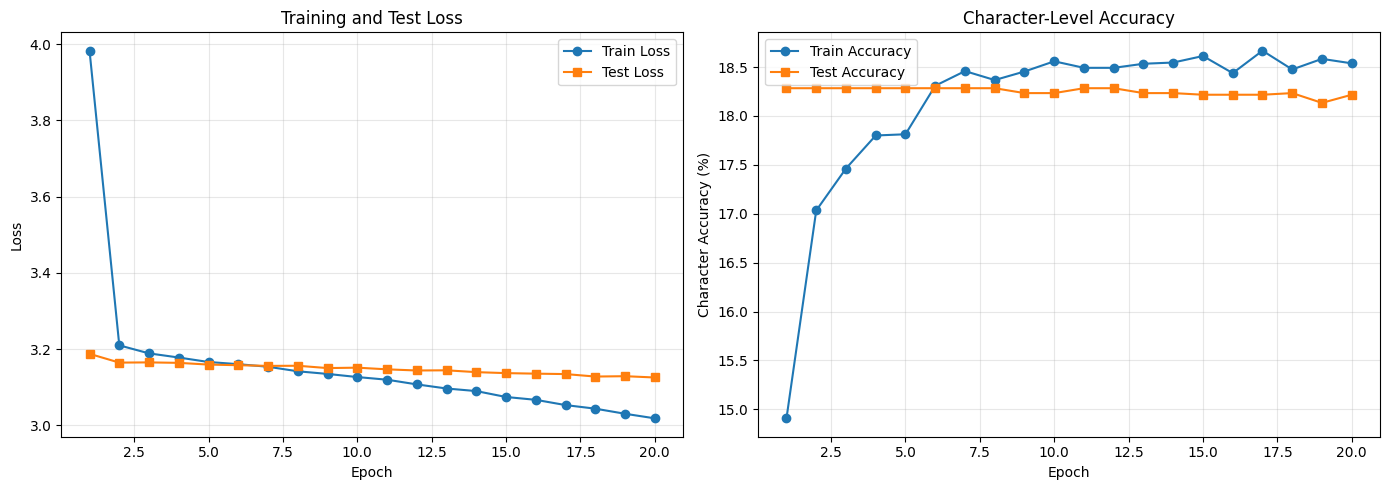


Final Results:
Train accuracy: 18.54%
Test accuracy: 18.22%


In [13]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax = axes[0]
ax.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
ax.plot(range(1, epochs+1), test_losses, marker='s', label='Test Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Test Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(range(1, epochs+1), train_accs, marker='o', label='Train Accuracy')
ax.plot(range(1, epochs+1), test_accs, marker='s', label='Test Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Character Accuracy (%)')
ax.set_title('Character-Level Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"Train accuracy: {train_accs[-1]:.2f}%")
print(f"Test accuracy: {test_accs[-1]:.2f}%")

## Part 5: Text Generation

Now let's use the model to generate text completions.

**Sampling strategies:**

1. **Greedy decoding** (temperature = 0): Always pick the most likely character
   - Deterministic, safe
   - Can be repetitive

2. **Temperature sampling** (temperature > 0): Sample from probability distribution
   - temperature = 1.0: Use model's probabilities directly
   - temperature < 1.0: More conservative (sharpen distribution)
   - temperature > 1.0: More creative (flatten distribution)

**Temperature formula:**
$$p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

where $z_i$ are the logits and $T$ is temperature.

In [14]:
def generate_completion(model, input_text, char_to_idx, idx_to_char, 
                       max_input_len, temperature=1.0):
    """
    Generate text completion for a given input.
    
    Args:
        model: Trained generative model
        input_text: Input string
        char_to_idx: Character to index mapping
        idx_to_char: Index to character mapping
        max_input_len: Maximum input length (for padding)
        temperature: Sampling temperature
    """
    # Encode input
    encoded = encode_sequence(input_text, char_to_idx)
    padded = pad_sequence(encoded, max_input_len, pad_value=0)
    
    # Convert to tensor
    input_tensor = torch.LongTensor([padded]).to(device)
    
    # Generate
    generated_ids = model.generate(input_tensor, temperature=temperature)
    
    # Decode
    generated_text = decode_sequence(generated_ids[0].cpu().numpy(), idx_to_char)
    
    return generated_text

In [15]:
# Test on some examples from test set
print("="*80)
print("TEXT GENERATION EXAMPLES")
print("="*80)

# Get some test examples
test_indices = [0, 5, 10, 15, 20]

for idx in test_indices:
    # Get original input and target
    input_seq = X_test[idx]
    target_seq = y_test[idx]
    
    # Decode to text (skip padding)
    input_text = decode_sequence(input_seq[input_seq != 0], idx_to_char)
    target_text = decode_sequence(target_seq[target_seq != 0], idx_to_char)
    
    # Generate with different temperatures
    generated_low = generate_completion(model, input_text, char_to_idx, idx_to_char, 
                                       max_input_len, temperature=0.5)
    generated_mid = generate_completion(model, input_text, char_to_idx, idx_to_char, 
                                       max_input_len, temperature=1.0)
    generated_high = generate_completion(model, input_text, char_to_idx, idx_to_char, 
                                        max_input_len, temperature=1.5)
    
    print(f"\nExample {idx+1}:")
    print(f"Input:              [{input_text}]")
    print(f"Ground Truth:       [{target_text}]")
    print(f"Generated (T=0.5):  [{generated_low}]")
    print(f"Generated (T=1.0):  [{generated_mid}]")
    print(f"Generated (T=1.5):  [{generated_high}]")
    print("-"*80)

TEXT GENERATION EXAMPLES

Example 1:
Input:              [الوزير محمد كبارة عبر قناة "الحدث": مباركة هي إستقالة الرئيس سعد #]
Ground Truth:       [الحريري من رئاسة الحكومة وهذا ]
Generated (T=0.5):  [ا اار ا وك ا تل و ووك ااااو   ]
Generated (T=1.0):  [تههبمرس،للاااهاال  يتو   له يه]
Generated (T=1.5):  [يم دوتيقت9ثيل ير❤لتومج أل8.b ،]
--------------------------------------------------------------------------------

Example 6:
Input:              [مع احترامنا الك معالي الوزير ،، #الفقراء ما بهمهم المالية العامة ! لا]
Ground Truth:       [نهم مش مستفيدين شي انتم المستف]
Generated (T=0.5):  [ ل رال ا لاال اارلاا    ةيااال]
Generated (T=1.0):  [دن شاكض مةا  غةقلرهب شوعنص لبم]
Generated (T=1.5):  [قضاد✍! /هدقدياا 🙆كمياءنزرا٣اهن]
--------------------------------------------------------------------------------

Example 11:
Input:              [رأس الحكمة في لبنان فخامة الرئيس #ميشال_عون يرفض اسقالة #سعد_الحريري]
Ground Truth:       [ وهذا تصرف حكيم من فخامته ويسد]
Generated (T=0.5):  [و ل ال

**Observations on temperature:**

- **T=0.5** (conservative): More likely to repeat common patterns, safer completions
- **T=1.0** (balanced): Uses model's learned probabilities, good balance
- **T=1.5** (creative): More diverse, can be more creative but also more errors

The "best" temperature depends on the application:
- Predictive text: Lower temperature (want safe, likely completions)
- Creative writing: Higher temperature (want diversity)
- Translation: Very low temperature (want accuracy)

## Part 6: Interactive Generation

Let's create a simple function to generate completions for custom input.

In [16]:
def complete_text(input_text, temperature=1.0):
    """
    Complete text with optional probability visualization.
    """
    completion = generate_completion(model, input_text, char_to_idx, idx_to_char, 
                                    max_input_len, temperature=temperature)
    
    print(f"\nInput: {input_text}")
    print(f"Completion: {completion}")
    print(f"Full text: {input_text}{completion}")
    
    return completion

# Try some custom inputs (you can modify these)
print("="*80)
print("CUSTOM TEXT COMPLETIONS")
print("="*80)

# Example 1: Start with Arabic text from the dataset
custom_input = inputs[0][:len(inputs[0])//2]  # Take first quarter of a tweet
complete_text(custom_input, temperature=1.0)

CUSTOM TEXT COMPLETIONS

Input: "أنا أؤمن بأن الانسان ينطفئ جماله
Completion: ايكملريها وانجطهام نهنيو لمًاف
Full text: "أنا أؤمن بأن الانسان ينطفئ جمالهايكملريها وانجطهام نهنيو لمًاف


'ايكملريها وانجطهام نهنيو لمًاف'

## Part 7: Summary

We built a **generative RNN** that completes sentences:

**What we did:**
1. Prepared Lebanese Arabic tweets for generation (input → target pairs)
2. Built a GRU-based generative model
3. **Fixed the padding issue**: Reserved index 0 for `<PAD>`, shifted all characters by +1
4. Trained with teacher forcing
5. Generated text with temperature-controlled sampling
6. Analyzed results with different temperatures

**Key concepts:**
- **Sequence-to-sequence prediction**: Each time step produces an output
- **Teacher forcing**: Use ground truth during training to speed convergence
- **Autoregressive generation**: Use own predictions during inference
- **Temperature sampling**: Control randomness/creativity in generation
- **Character-level modeling**: Learn from character sequences
- **Padding handling**: Separate padding token from actual characters (especially spaces!)

**Key lessons:**
- Generation is harder than classification
- Small datasets limit what can be learned
- Temperature is a useful knob for controlling output
- Character-level is pedagogically clear but not ideal for production
- Proper handling of special tokens (padding, spaces) is crucial
- Modern systems use transformers, larger datasets, and subword encoding

**Next steps to explore:**
- Word-level modeling
- Attention mechanisms
- Transformer architecture (GPT-style)
- Fine-tuning pre-trained models
- Evaluation metrics (perplexity, BLEU)